# 02 - HAM10000 — Segmentation EDA

HAM10000 is the **training set for the Mask R-CNN**, so the segmentation **masks are the target** and
this EDA focuses on them: full-dataset mask availability & integrity, mask quality, and lesion
area / object-scale distribution (which informs anchor/scale design). Class balance and demographics
are included only as **dataset context**, since diagnosis labels are not used to train the segmenter.

Training the Mask R-CNN model is handled by `scripts/train_segmenter.py` (run from the repo root with `PYTHONPATH=src`) —
keeping the heavy compute out of Jupyter avoids kernel-crash issues over SSH.

In [1]:
import os
import sys
from pathlib import Path

current = Path.cwd().resolve()
PROJECT_ROOT = next(
    path
    for path in [current, *current.parents]
    if (path / "pyproject.toml").exists()
)

os.environ["SCD_DATA_DIR"] = str(PROJECT_ROOT / "data")
os.environ["SCD_HAM10000_DIR"] = str(
    PROJECT_ROOT / "data" / "buckets" / "HAM10000"
)
os.environ["SCD_ISIC_DIR"] = str(
    PROJECT_ROOT / "data" / "buckets" / "ISIC_archive"
)
os.environ["SCD_ISIC_IMAGES_DIR"] = str(
    PROJECT_ROOT / "data" / "buckets" / "ISIC_archive"
)
os.environ["SCD_ISIC_MASKS_DIR"] = str(
    PROJECT_ROOT / "data" / "buckets" / "ISIC_masks"
)

sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT:", PROJECT_ROOT)
print("HAM10000:", os.environ["SCD_HAM10000_DIR"])

PROJECT_ROOT: /home/indalecio.rios/scd-ml
HAM10000: /home/indalecio.rios/scd-ml/data/buckets/HAM10000


In [2]:
from src.paths import HAM10000_DIR, EDA_HAM10000_DIR
from src.viz import setup_style, save_fig, HAM_CLASS_COLORS

In [3]:
from PIL import Image
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

setup_style()
pd.set_option('display.max_columns', None)

In [4]:
# Load HAM10000 metadata
meta_df = pd.read_csv(os.path.join(HAM10000_DIR, "metadata.csv"))
n_images = len(os.listdir(os.path.join(HAM10000_DIR, "images")))
n_masks = len(os.listdir(os.path.join(HAM10000_DIR, "masks")))

print(f"Metadata rows: {len(meta_df):,}")
print(f"Images on disk: {n_images:,}")
print(f"Masks on disk:  {n_masks:,}")
print(f"\nColumns: {list(meta_df.columns)}")
meta_df.head()

Metadata rows: 10,015
Images on disk: 10,015
Masks on disk:  10,015

Columns: ['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization', 'dataset']


,lesion_id,image_id,dx,dx_type,age,sex,localization,dataset
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,vidir_modern
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,vidir_modern
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,vidir_modern
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,vidir_modern
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,vidir_modern


## 1. Mask availability & integrity audit

The mask is the **training target** for the Mask R-CNN, so every training image must have a valid,
non-empty mask whose dimensions match the image. This section runs a **full-dataset** pass (not a
sample) and builds a per-image `mask_stats` table reused by the following sections. It reconciles
metadata ↔ images-on-disk ↔ masks-on-disk and flags the failure modes that break segmentation training:
missing masks, empty (all-zero) masks, degenerate (all-foreground) masks, and image/mask size mismatches.

In [5]:
# Full-dataset pass: one row per metadata image_id, opening its image + mask once.
# scipy is optional — used only for connected-component counting.
from tqdm.auto import tqdm
try:
    from scipy import ndimage as _ndi
    _HAS_SCIPY = True
except ImportError:
    _HAS_SCIPY = False
    print("scipy not available — n_components will be NaN (mask-quality still works).")

images_dir = os.path.join(HAM10000_DIR, "images")
masks_dir = os.path.join(HAM10000_DIR, "masks")

records = []
for image_id in tqdm(
    meta_df["image_id"],
    total=len(meta_df),
    desc="Auditing HAM10000 image/mask pairs",
    unit="pair",
):
    img_path = os.path.join(images_dir, f"{image_id}.jpg")
    mask_path = os.path.join(masks_dir, f"{image_id}_segmentation.png")

    rec = {'image_id': image_id,
           'has_image': os.path.exists(img_path),
           'has_mask': os.path.exists(mask_path),
           'img_w': None, 'img_h': None, 'mask_w': None, 'mask_h': None,
           'fg_px': None, 'area_pct': None, 'n_components': None,
           'touches_border': None}

    if rec['has_image']:
        with Image.open(img_path) as im:
            rec['img_w'], rec['img_h'] = im.size

    if rec['has_mask']:
        m = np.array(Image.open(mask_path).convert('L'))
        binary = m > 127                      # robust threshold (masks are 0/255)
        rec['mask_h'], rec['mask_w'] = binary.shape
        rec['fg_px'] = int(binary.sum())
        rec['area_pct'] = rec['fg_px'] / binary.size * 100
        rec['touches_border'] = bool(
            binary[0, :].any() or binary[-1, :].any()
            or binary[:, 0].any() or binary[:, -1].any()
        )
        if _HAS_SCIPY and rec['fg_px'] > 0:
            _, rec['n_components'] = _ndi.label(binary)

    records.append(rec)

mask_stats = pd.DataFrame.from_records(records)
mask_stats['dims_match'] = (
    (mask_stats['img_w'] == mask_stats['mask_w'])
    & (mask_stats['img_h'] == mask_stats['mask_h'])
)

# ── Reconciliation ────────────────────────────────────────────────────────────
mask_files = {f.replace('_segmentation.png', '')
              for f in os.listdir(masks_dir) if f.endswith('_segmentation.png')}
meta_ids = set(meta_df['image_id'])

print("=== Availability reconciliation ===")
print(f"Metadata rows:            {len(meta_df):,}")
print(f"Images on disk:           {n_images:,}")
print(f"Masks on disk:            {n_masks:,}")
print(f"Metadata rows w/o image:  {(~mask_stats['has_image']).sum():,}")
print(f"Metadata rows w/o mask:   {(~mask_stats['has_mask']).sum():,}")
print(f"Masks on disk w/o metadata row: {len(mask_files - meta_ids):,}")

print("\n=== Mask integrity (over masks that exist) ===")
present = mask_stats[mask_stats['has_mask']]
print(f"Masks analyzed:           {len(present):,}")
print(f"Empty (all-zero) masks:   {(present['fg_px'] == 0).sum():,}")
full = present['area_pct'] >= 99.0
print(f"Degenerate (>=99% fg):    {int(full.sum()):,}")
print(f"Image/mask size mismatch: {int((~mask_stats['dims_match'] & mask_stats['has_mask'] & mask_stats['has_image']).sum()):,}")

/home/indalecio.rios/scd-ml/.venv-mask/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Auditing HAM10000 image/mask pairs:   0%|          | 0/10015 [00:00<?, ?pair/s]

Auditing HAM10000 image/mask pairs: 100%|██████████| 10015/10015 [17:08<00:00,  9.74pair/s]


=== Availability reconciliation ===
Metadata rows:            10,015
Images on disk:           10,015
Masks on disk:            10,015
Metadata rows w/o image:  0
Metadata rows w/o mask:   0
Masks on disk w/o metadata row: 0

=== Mask integrity (over masks that exist) ===
Masks analyzed:           10,015
Empty (all-zero) masks:   0
Degenerate (>=99% fg):    3
Image/mask size mismatch: 0


## 2. Mask quality

Beyond mere existence, mask *quality* affects Mask R-CNN training. From the full-dataset `mask_stats`
we check: the foreground-coverage distribution, tiny/huge outliers, how many masks are **multi-component**
(more than one connected blob — the loader/annotation assumes one lesion per image), and how many masks
**touch the image border** (which clips the derived bounding box).

Valid (non-empty) masks:      10,015
Tiny masks (<1% area):        51
Huge masks (>90% area):       45
Masks touching image border:  1,594  (15.9%)
Multi-component masks (>1 blob): 112  (1.1%)

Foreground coverage (% of image) — describe:
count    10015.00
mean        26.63
std         18.84
min          0.39
25%         11.95
50%         22.23
75%         37.41
max        100.00


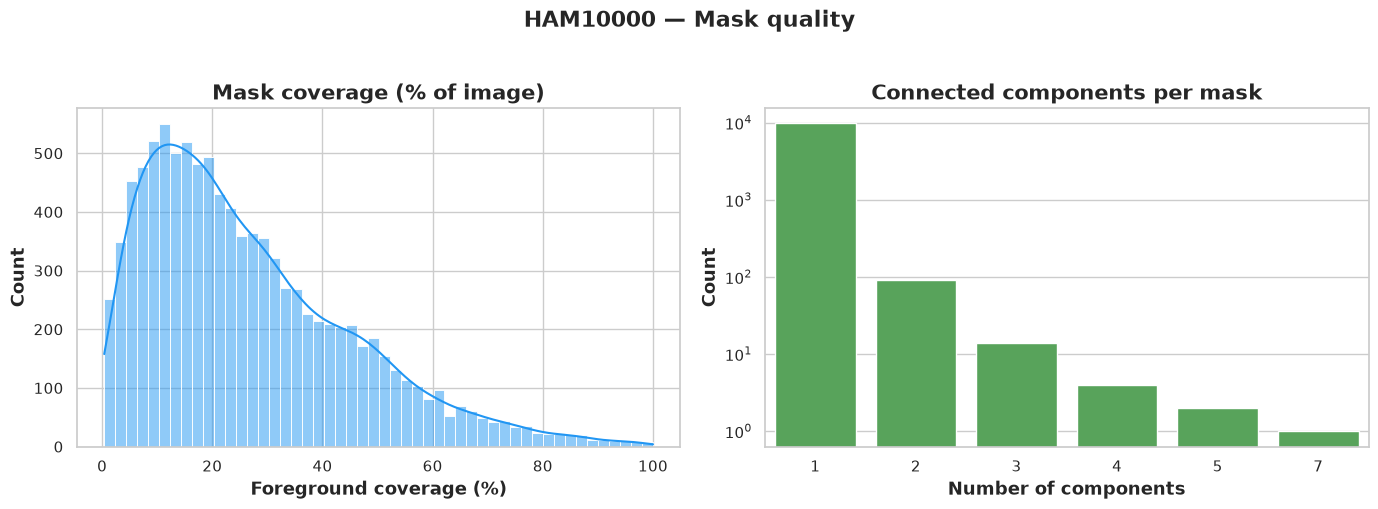

In [6]:
valid = mask_stats[(mask_stats['has_mask']) & (mask_stats['fg_px'] > 0)].copy()

# Quality flags
tiny = valid['area_pct'] < 1.0
huge = valid['area_pct'] > 90.0
border = valid['touches_border'] == True
multi = valid['n_components'] > 1 if valid['n_components'].notna().any() else None

print(f"Valid (non-empty) masks:      {len(valid):,}")
print(f"Tiny masks (<1% area):        {int(tiny.sum()):,}")
print(f"Huge masks (>90% area):       {int(huge.sum()):,}")
print(f"Masks touching image border:  {int(border.sum()):,}  ({border.mean()*100:.1f}%)")
if multi is not None:
    print(f"Multi-component masks (>1 blob): {int(multi.sum()):,}  ({multi.mean()*100:.1f}%)")
print("\nForeground coverage (% of image) — describe:")
print(valid['area_pct'].describe().round(2).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(valid['area_pct'], bins=50, kde=True, color='#2196F3', ax=axes[0])
axes[0].set_title('Mask coverage (% of image)')
axes[0].set_xlabel('Foreground coverage (%)')
axes[0].set_ylabel('Count')

if valid['n_components'].notna().any():
    comp_counts = valid['n_components'].value_counts().sort_index()
    sns.barplot(x=comp_counts.index.astype(int), y=comp_counts.values,
                color='#4CAF50', ax=axes[1])
    axes[1].set_title('Connected components per mask')
    axes[1].set_xlabel('Number of components')
    axes[1].set_ylabel('Count')
    axes[1].set_yscale('log')
else:
    axes[1].text(0.5, 0.5, 'scipy unavailable —\nno component analysis',
                 ha='center', va='center')
    axes[1].axis('off')

fig.suptitle('HAM10000 — Mask quality', y=1.02)
plt.tight_layout()
save_fig(fig, EDA_HAM10000_DIR, '01_mask_quality')
plt.show()

## 3. Lesion area / object-scale distribution

Over the **full dataset** (from `mask_stats`): image-dimension uniformity and the lesion object-scale
distribution (foreground pixels and % of image). This is a direct input to Mask R-CNN **anchor / scale**
design — how big lesions are relative to the frame determines useful anchor sizes.

Images with dimensions: 10,015
Distinct (width, height) pairs: 1
         img_w    img_h
count  10015.0  10015.0
mean     600.0    450.0
std        0.0      0.0
min      600.0    450.0
25%      600.0    450.0
50%      600.0    450.0
75%      600.0    450.0
max      600.0    450.0


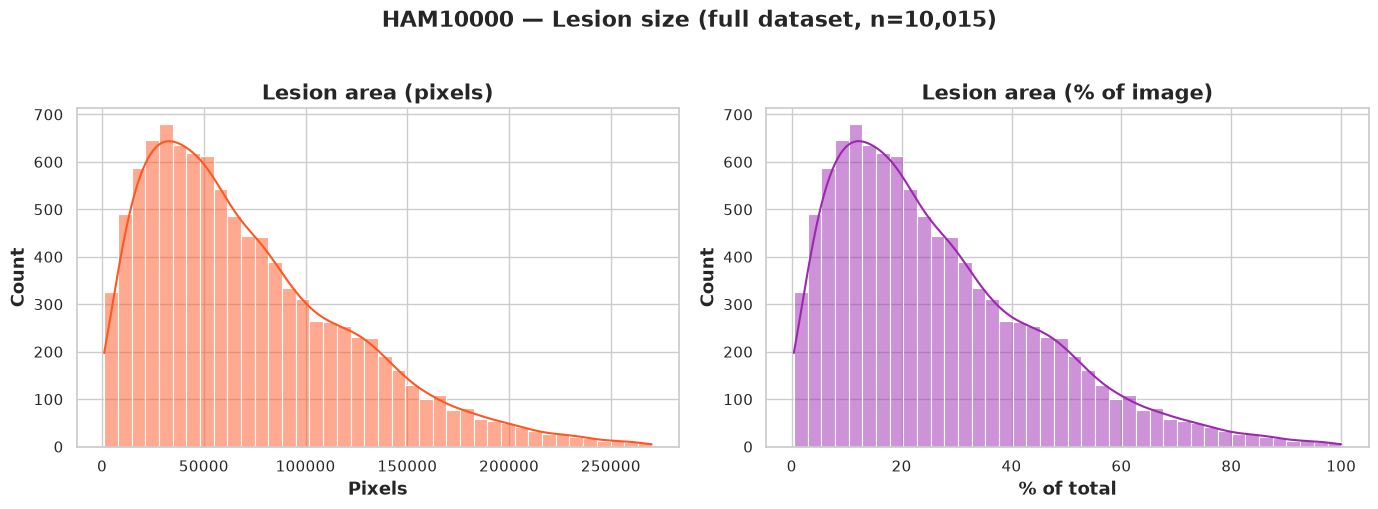

In [7]:
# Full-dataset image dimensions (from mask_stats — no re-sampling)
dims_df = mask_stats.dropna(subset=['img_w', 'img_h'])[['img_w', 'img_h']]
n_unique_dims = dims_df.drop_duplicates().shape[0]
print(f"Images with dimensions: {len(dims_df):,}")
print(f"Distinct (width, height) pairs: {n_unique_dims}")
print(dims_df.describe().round(1))
if n_unique_dims > 1:
    print("\nTop image sizes:")
    print(dims_df.value_counts().head().to_string())

# Full-dataset lesion area (non-empty masks)
area_px = valid['fg_px']
area_pct = valid['area_pct']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(area_px, bins=40, kde=True, color='#FF5722', ax=axes[0])
axes[0].set_title('Lesion area (pixels)')
axes[0].set_xlabel('Pixels')
sns.histplot(area_pct, bins=40, kde=True, color='#9C27B0', ax=axes[1])
axes[1].set_title('Lesion area (% of image)')
axes[1].set_xlabel('% of total')
fig.suptitle(f'HAM10000 — Lesion size (full dataset, n={len(valid):,})', y=1.02)
plt.tight_layout()
save_fig(fig, EDA_HAM10000_DIR, '02_lesion_area')
plt.show()

## 4. Sample images with ground-truth mask overlay

Visual quality check of the segmentation target: image next to its GT-mask overlay. Samples are drawn
across diagnoses to cover varied lesion appearances. Missing image/mask files are **reported**, not
skipped silently — a missing mask is exactly the failure this EDA is meant to surface.

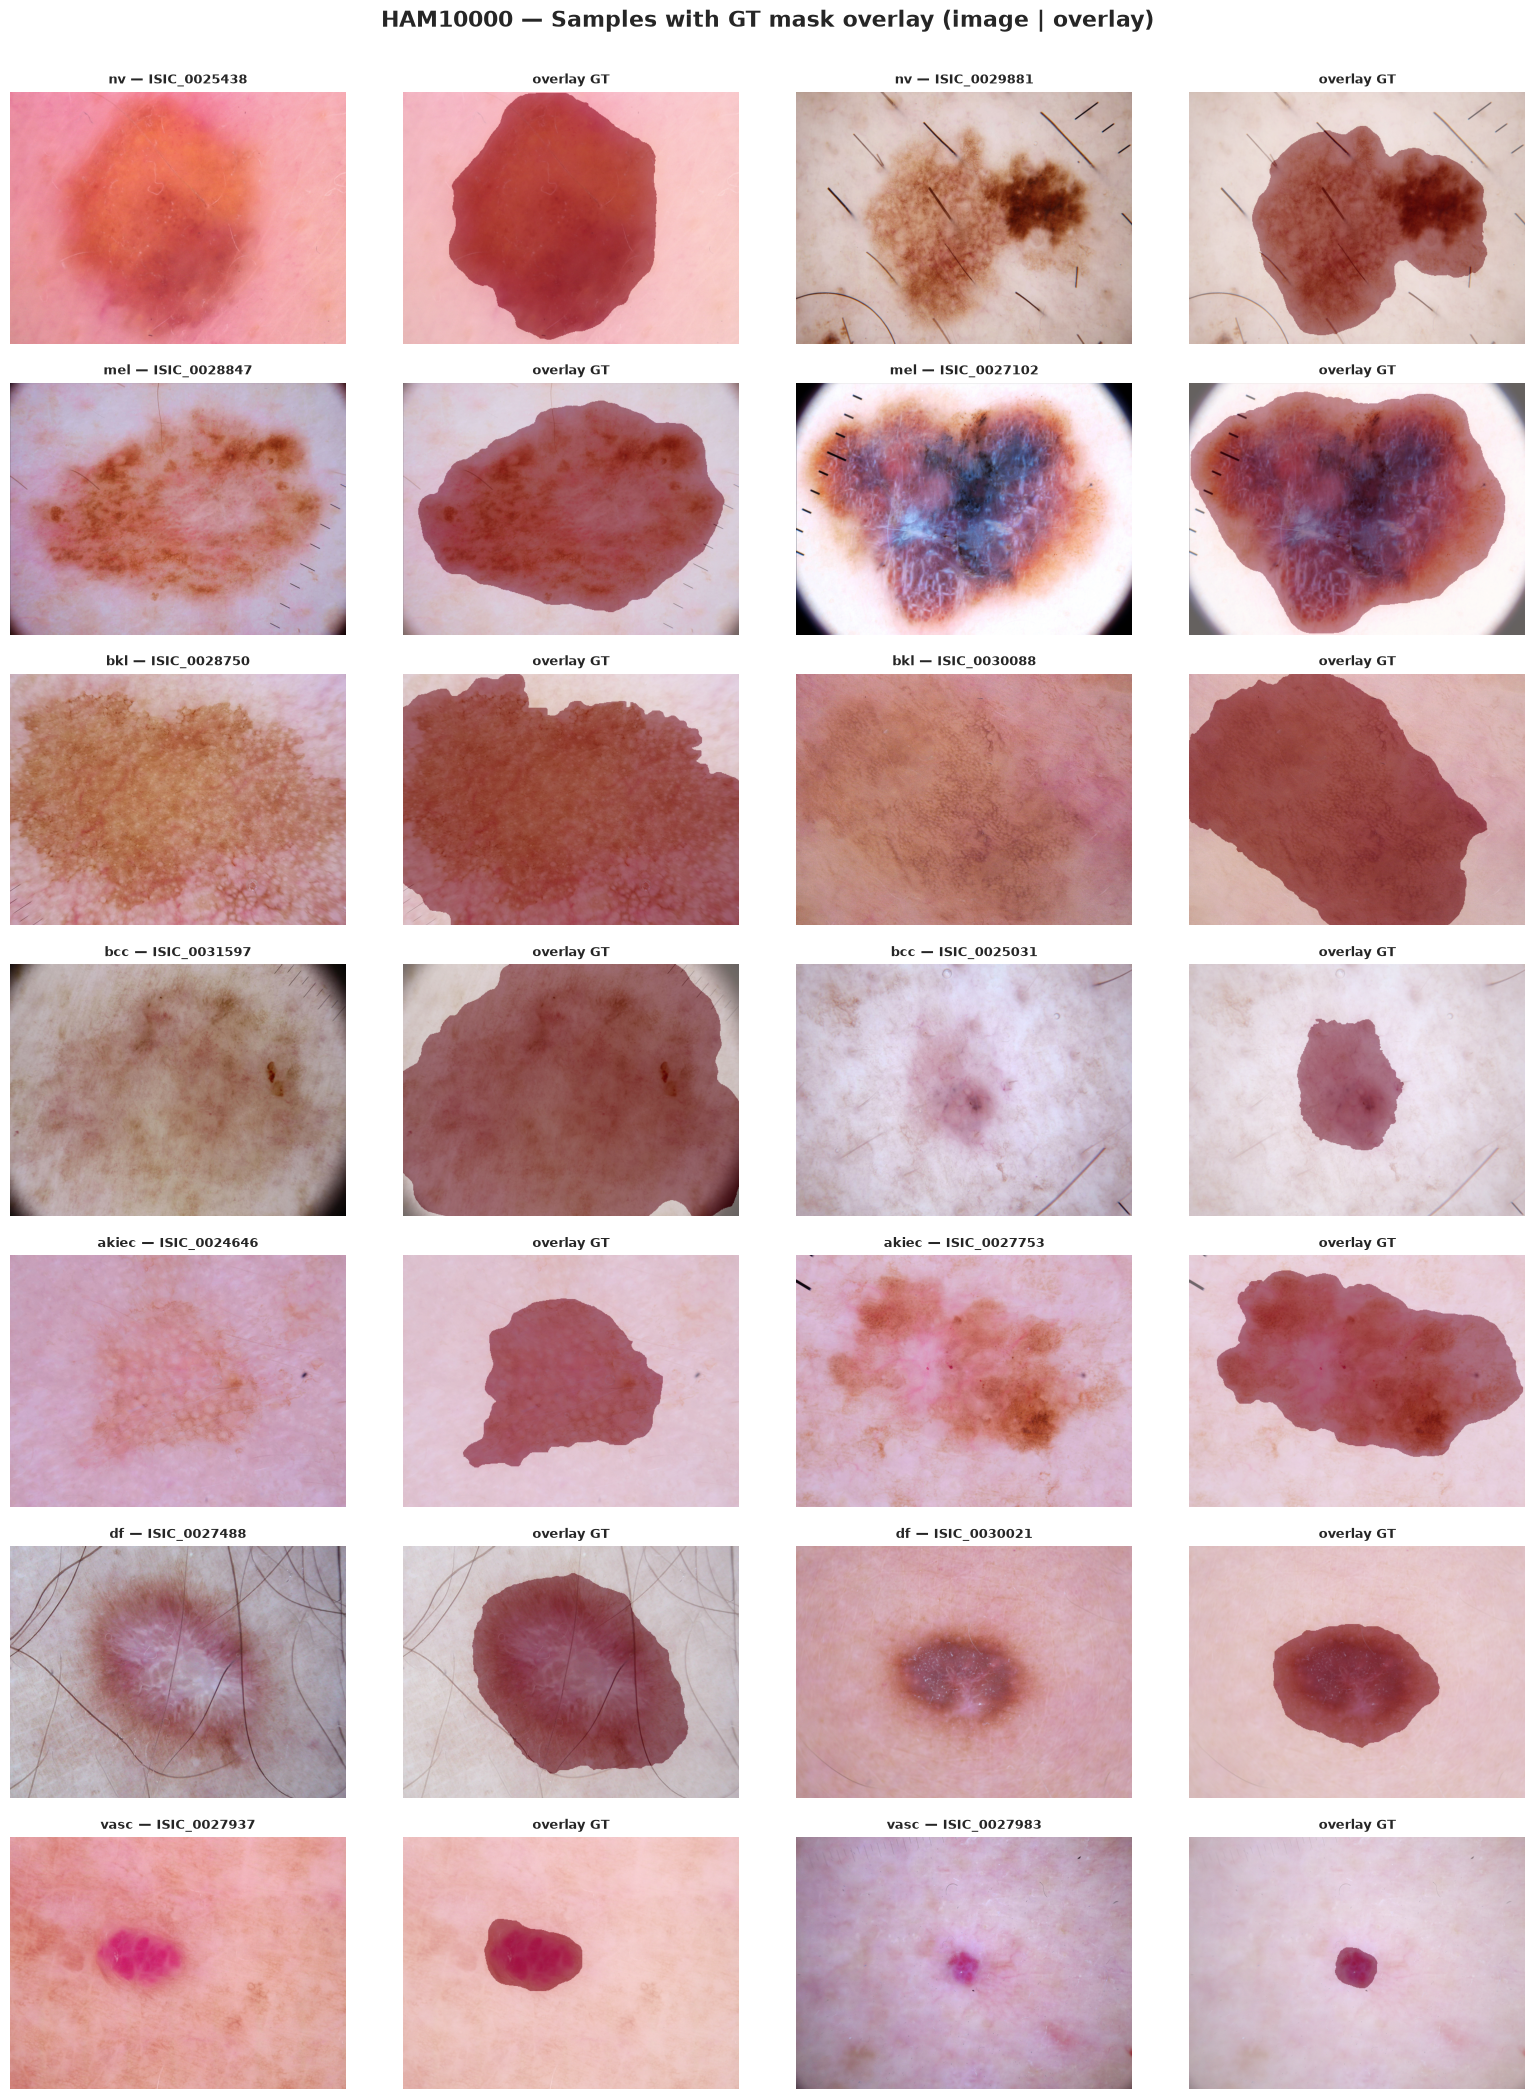

In [8]:
# Sample across diagnoses to get varied lesion appearances (dx used only for diversity, not as a target)
classes = ['nv', 'mel', 'bkl', 'bcc', 'akiec', 'df', 'vasc']
n_per_class = 2

fig, axes = plt.subplots(
    len(classes), n_per_class * 2,
    figsize=(4 * n_per_class * 2, 3 * len(classes)),
)
fig.suptitle('HAM10000 — Samples with GT mask overlay (image | overlay)', y=1.0)

missing = []
for row, cls in enumerate(classes):
    cls_ids = (
        meta_df[meta_df['dx'] == cls]['image_id']
        .sample(n=n_per_class, random_state=42)
        .tolist()
    )
    for col_i, img_id in enumerate(cls_ids):
        img_path = os.path.join(images_dir, f"{img_id}.jpg")
        mask_path = os.path.join(masks_dir, f"{img_id}_segmentation.png")

        ax_img = axes[row, col_i * 2]
        ax_over = axes[row, col_i * 2 + 1]

        if not (os.path.exists(img_path) and os.path.exists(mask_path)):
            missing.append(img_id)
            for ax in (ax_img, ax_over):
                ax.text(0.5, 0.5, f"MISSING\n{img_id}", ha='center', va='center',
                        fontsize=9, color='red')
                ax.axis('off')
            continue

        img_np = np.array(Image.open(img_path).convert('RGB'))
        mask_np = np.array(Image.open(mask_path).convert('L'))

        ax_img.imshow(img_np)
        ax_img.set_title(f"{cls} — {img_id}", fontsize=9)
        ax_img.axis('off')

        ax_over.imshow(img_np)
        ax_over.imshow(mask_np, alpha=0.4, cmap='Reds')
        ax_over.set_title('overlay GT', fontsize=9)
        ax_over.axis('off')

if missing:
    print(f"WARNING: {len(missing)} sampled image(s) missing image or mask: {missing}")

plt.tight_layout()
save_fig(fig, EDA_HAM10000_DIR, '03_samples_overlay')
plt.show()

## 5. Dataset context: class balance

The Mask R-CNN is **class-agnostic** (one "lesion" foreground class), so the diagnosis (`dx`) label is
**not** a training target here — it is shown only as dataset context. HAM10000 is famously imbalanced
(`nv`, melanocytic nevi, dominates). This matters for segmentation mainly as a **sampling** concern:
if some lesion morphologies are rare, consider whether the train/val split exposes the model to enough
of the harder cases — not as a loss-weighting issue for a classifier.

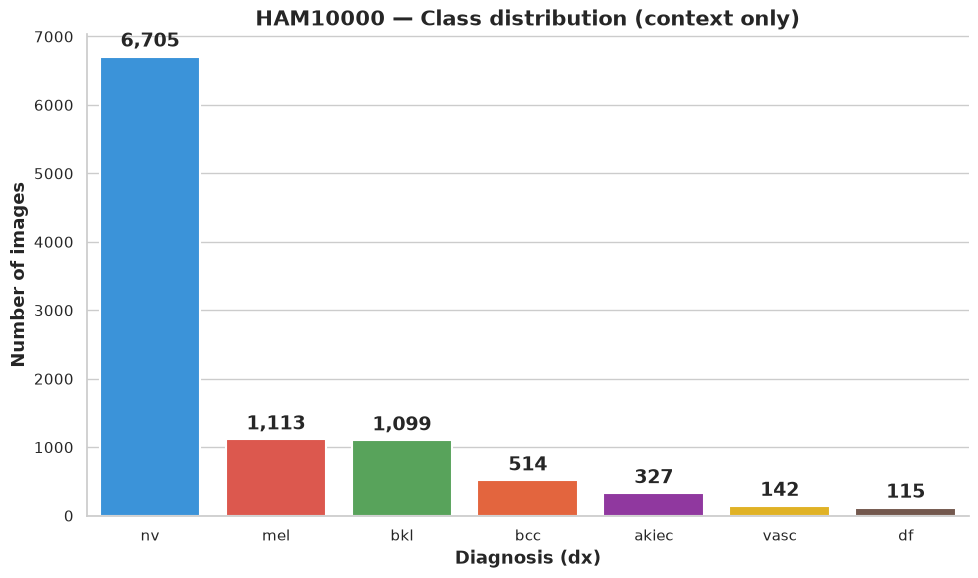


Percentage per class:
dx
nv       66.95
mel      11.11
bkl      10.97
bcc       5.13
akiec     3.27
vasc      1.42
df        1.15


In [9]:
dx_counts = meta_df['dx'].value_counts()

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    x=dx_counts.index, y=dx_counts.values,
    hue=dx_counts.index, palette=HAM_CLASS_COLORS,
    edgecolor='white', linewidth=1.5, legend=False, ax=ax,
)
for bar, val in zip(ax.patches, dx_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + dx_counts.max() * 0.012,
        f'{val:,}', ha='center', va='bottom', fontweight='bold',
    )
ax.set_xlabel('Diagnosis (dx)')
ax.set_ylabel('Number of images')
ax.set_title('HAM10000 — Class distribution (context only)')
sns.despine(ax=ax)
plt.tight_layout()
save_fig(fig, EDA_HAM10000_DIR, '04_dx_distribution')
plt.show()

print("\nPercentage per class:")
print((dx_counts / dx_counts.sum() * 100).round(2).to_string())

## 6. Dataset context: demographics & localization

Age, sex and anatomical-site distributions — dataset context, not segmentation inputs.

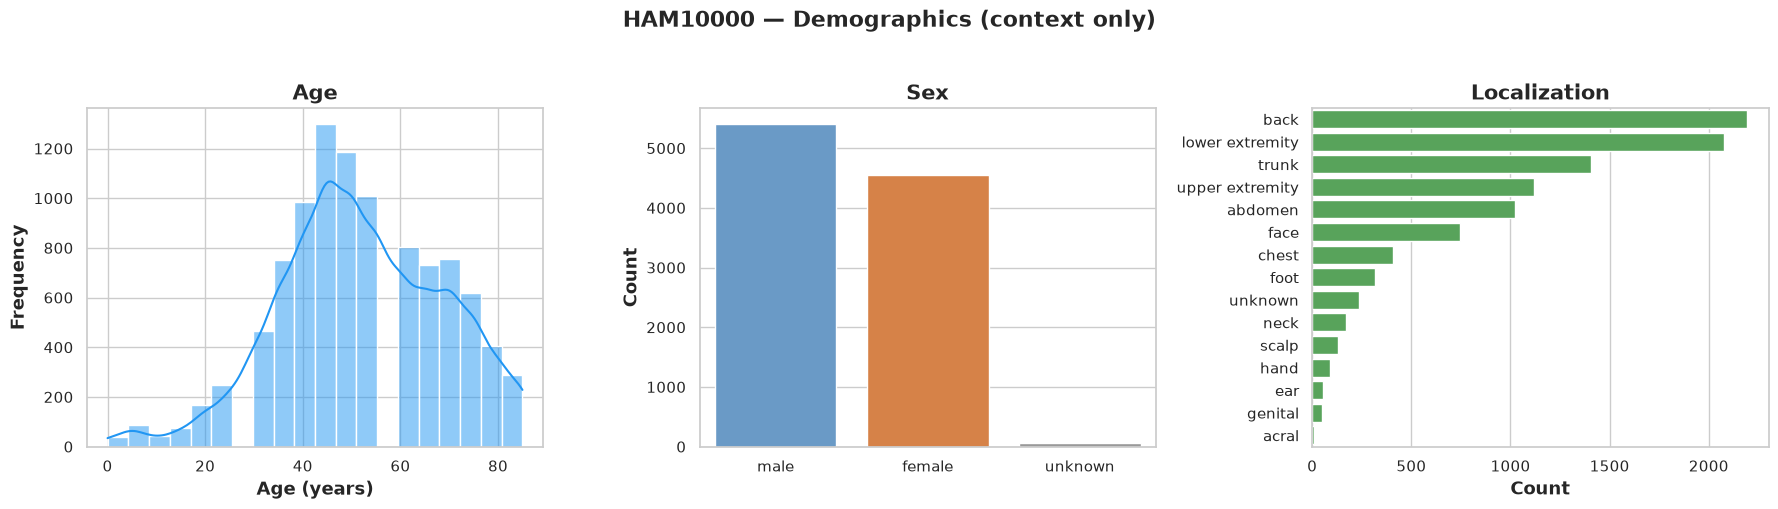

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(data=meta_df, x='age', bins=20, kde=True, color='#2196F3', ax=axes[0])
axes[0].set_title('Age')
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Frequency')

sex_counts = meta_df['sex'].value_counts()
sns.barplot(
    x=sex_counts.index, y=sex_counts.values,
    hue=sex_counts.index,
    palette=['#5B9BD5', '#ED7D31', '#999999'][:len(sex_counts)],
    legend=False, ax=axes[1],
)
axes[1].set_title('Sex')
axes[1].set_xlabel('')
axes[1].set_ylabel('Count')

loc_counts = meta_df['localization'].value_counts()
sns.barplot(y=loc_counts.index, x=loc_counts.values, color='#4CAF50', ax=axes[2])
axes[2].set_title('Localization')
axes[2].set_xlabel('Count')
axes[2].set_ylabel('')

fig.suptitle('HAM10000 — Demographics (context only)', y=1.02)
plt.tight_layout()
save_fig(fig, EDA_HAM10000_DIR, '05_demographics')
plt.show()

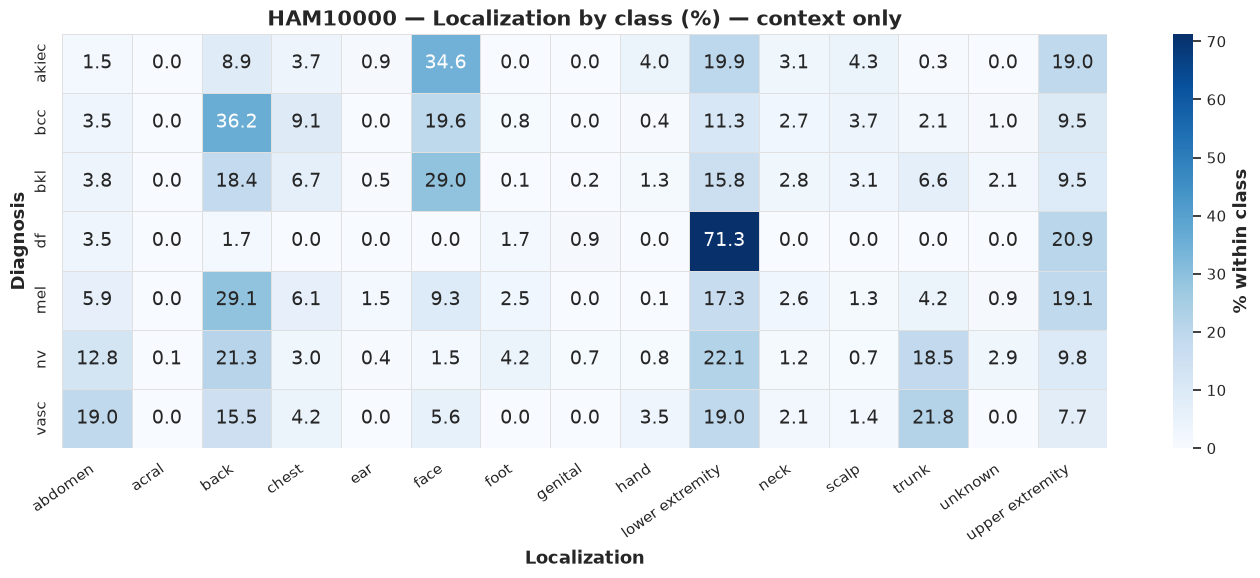

In [11]:
# Class × anatomical localization (row-normalized %) — context only
heatmap_data = (
    meta_df.groupby(['dx', 'localization']).size()
    .reset_index(name='count')
    .pivot(index='dx', columns='localization', values='count')
    .fillna(0)
)
heatmap_pct = heatmap_data.div(heatmap_data.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    heatmap_pct, annot=True, fmt='.1f', cmap='Blues',
    linewidths=0.5, linecolor='#e0e0e0',
    cbar_kws={'label': '% within class'}, ax=ax,
)
ax.set_title('HAM10000 — Localization by class (%) — context only')
ax.set_xlabel('Localization')
ax.set_ylabel('Diagnosis')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
save_fig(fig, EDA_HAM10000_DIR, '06_dx_x_localization')
plt.show()

## 7. Lesion grouping (train/val split leakage)

HAM10000 contains **multiple images of the same lesion** (`lesion_id`). If the train/val split for the
Mask R-CNN is done per-image, images of the same lesion can land on both sides and inflate validation
segmentation metrics. The split should be **grouped by `lesion_id`**. The cell below quantifies the
redundancy.

In [12]:
if 'lesion_id' in meta_df.columns:
    n_total = len(meta_df)
    n_lesions = meta_df['lesion_id'].nunique()
    imgs_per_lesion = meta_df.groupby('lesion_id').size()
    multi = (imgs_per_lesion > 1).sum()

    print(f"Total images:            {n_total:,}")
    print(f"Unique lesion_id:        {n_lesions:,}  ({n_total / n_lesions:.2f} imgs/lesion)")
    print(f"Lesions with > 1 image:  {multi:,}")
    print("\nImages-per-lesion distribution:")
    print(imgs_per_lesion.describe().round(2).to_string())
    print("\n→ Use GroupShuffleSplit / StratifiedGroupKFold on lesion_id when splitting for training.")
else:
    print("No 'lesion_id' column in metadata — cannot assess lesion-level leakage.")

Total images:            10,015
Unique lesion_id:        7,470  (1.34 imgs/lesion)
Lesions with > 1 image:  1,956

Images-per-lesion distribution:
count    7470.00
mean        1.34
std         0.63
min         1.00
25%         1.00
50%         1.00
75%         2.00
max         6.00

→ Use GroupShuffleSplit / StratifiedGroupKFold on lesion_id when splitting for training.
